In [5]:
import pandas as pd

import matplotlib.pyplot as plt

import numpy as np

df = pd.read_csv('low_speed_data_v2x_rtk2.csv')

print(df)

      timestamp_gnss  timestamp_cam  distance  velocity_imu  velocity_cam  \
0       1.762458e+09   1.762465e+09  5.352943      0.556115         0.000   
1       1.762458e+09   1.762465e+09  5.325521      0.662311         0.000   
2       1.762458e+09   1.762465e+09  5.300640      0.727431         0.000   
3       1.762458e+09   1.762465e+09  5.246941      0.933938         0.000   
4       1.762458e+09   1.762465e+09  5.226188      1.324163         0.000   
...              ...            ...       ...           ...           ...   
1063    1.762458e+09   1.762466e+09  0.777210      2.151117         3.492   
1064    1.762458e+09   1.762466e+09  0.785226      1.144264         0.684   
1065    1.762458e+09   1.762466e+09  0.755310      0.802435         0.036   
1066    1.762458e+09   1.762466e+09  0.758685      0.586146         0.036   
1067    1.762458e+09   1.762466e+09  0.747490      0.375487         0.000   

        rtk   lat_gnss  long_gnss    lat_cam   long_cam  
0      True -22.8

In [6]:
distance = df['distance'].to_numpy()
v_imu = df['velocity_imu'].to_numpy()
v_cam = df['velocity_cam'].to_numpy()
rtk = df['rtk'].to_numpy()

t = df['timestamp_gnss'].to_numpy()

t = t - t[0]

In [7]:
distance_rtk = []
distance_nrtk = []

for i in range(len(distance)):
    if (rtk[i] > 0):
        distance_rtk.append(distance[i])
    else:
        distance_nrtk.append(distance[i])
        


distance_mean = np.mean(distance)

distance_std = np.std(distance)

distance_var = np.var(distance)

distance_mean_rtk = np.mean(distance_rtk)

distance_std_rtk = np.std(distance_rtk)

distance_var_rtk = np.var(distance_rtk)

distance_mean_nrtk = np.mean(distance_nrtk)

distance_std_nrtk = np.std(distance_nrtk)

distance_var_nrtk = np.var(distance_nrtk)


print("distance_mean: "+str(distance_mean))
print("distance_std: "+str(distance_std))
print("distance_var: "+str(distance_var))

print("distance_mean_rtk: "+str(distance_mean_rtk))
print("distance_std_rtk: "+str(distance_std_rtk))
print("distance_var_rtk: "+str(distance_var_rtk))

print("distance_mean_nrtk: "+str(distance_mean_nrtk))
print("distance_std_nrtk: "+str(distance_std_nrtk))
print("distance_var_nrtk: "+str(distance_var_nrtk))

distance_mean: 2.833710081771098
distance_std: 2.3565390227490246
distance_var: 5.553276165738929
distance_mean_rtk: 5.304213912149324
distance_std_rtk: 0.7287024983218876
distance_var_rtk: 0.5310073310605605
distance_mean_nrtk: 0.7234880599896957
distance_std_nrtk: 0.4204547851902846
distance_var_nrtk: 0.17678222638940838


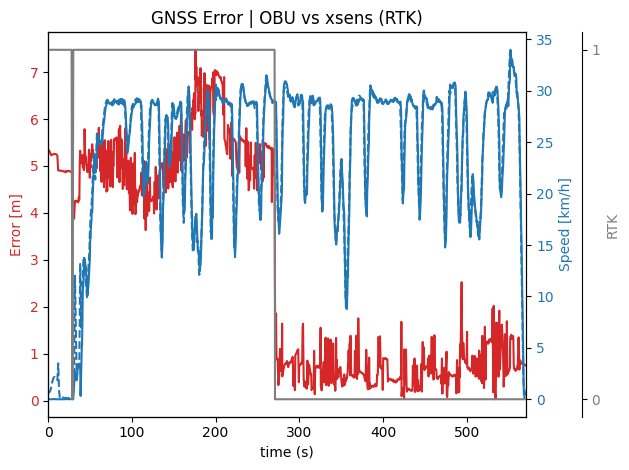

In [17]:
fig, ax1 = plt.subplots()

plt.title("GNSS Error | OBU vs xsens (RTK)")

color = 'tab:red'
ax1.set_xlabel('time (s)')
ax1.set_ylabel('Error [m]', color=color)
ax1.plot(t, distance, color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xlim(t[0],t[len(t)-1])
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = 'tab:blue'
ax2.set_ylabel('Speed [km/h]', color=color)  # we already handled the x-label with ax1
ax2.plot(t, v_cam, color=color)
ax2.plot(t, v_imu, color=color, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

ax3 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis
ax3.spines['right'].set_position(('outward', 40)) # Adjust '60' as needed for spacing
color = 'tab:gray'
ax3.set_ylabel('RTK', color=color)  # we already handled the x-label with ax1
ax3.plot(t, rtk, color=color)
ax3.tick_params(axis='y', labelcolor=color)
ax3.set_yticks([0, 1])
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.savefig("gnss_error.png")

plt.show()

Histogram error / velocity